# **Procesamiento de Lenguaje Natural**
## Maestría en Inteligencia Artificial Aplicada
### Tecnológico de Monterrey

* **Nombres y matriculas**
    * Sarmiento Cervantes Jacqueline: A01795863
    * Mayoral Teran Alexandro: A01795899
* **Numero de equipo: 8**

---

# 🎓 Proyecto Integrador: Avance 4 - Evaluación Core, Pareto y Métricas Base (DISF)

Este documento es el **entregable** del Avance 4 y funge como la base teórica y técnica para la evaluación del sistema. Su estructura fluye de lo fundacional (arquitectura y telemetría) hacia la validación estadística (Pareto y Taxonomía de errores), cumpliendo con las exigencias de Banco de México y las rúbricas del avance.


## 1. Alineación con la Rúbrica Equivalente (MA1-MA7)

La rúbrica equivalente del Avance 4 se traduce a evidencia específica para un sistema RAG. Por eso, antes de entrar al detalle técnico, se muestra una matriz de alineación que conecta cada punto MA1-MA7 con archivos, resultados y decisiones del proyecto.

Las tablas de esta sección y de las secciones posteriores se generan con `src/utils/resultados_avance4.py`. La función guarda copias en `docs/entregas/tablas_avance4/` y las despliega en el notebook para que el entregable sea reproducible.

| Rúbrica | Evidencia | Acción |
| --- | --- | --- |
| MA1 | 6 configuraciones RAG; corrida local self-hostable con llama3.1:8b/Ollama para residencia de datos. | Definir cada candidato como configuracion completa: retriever + expansion + reranker + backend LLM. |
| MA2 | Eval set congelado de 109 consultas; balance por dominio/dificultad/longitud; Pareto y no-context por backend. | Mostrar perfil del dataset, exact-match vs LLM judge y contaminacion ciega asociada a cada candidato. |
| MA3 | prompts.json + prompts_registry.py; prompt_id=qa_rag, version=1.0.0, hash=2cbbc4f704. | Reportar prompt versionado/hash en la tabla de candidatos junto con embedding/reranker/fine-tuning. |
| MA4 | Top-2 operativo: 2_Baseline_Semántico y 6_SOTA_Completo; eval set congelado desde E3 y sin tuning sobre el test final. | Declarar held-out/leakage guardrail y reconocer limite si no se ejecuta nuevo ajuste profundo. |
| MA5 | Bootstrap CI de 1000 remuestreos + Paired-t por query + McNemar sobre hit/miss + bootstrap pareado. | Tratar CIs con cero como empate estadístico; elegir por costo/latencia e indicar temperatura=0/varianza no estimada. |
| MA6 | Taxonomía A/B/C, contaminación y desempeño por candidato desagregado por dominio, dificultad y longitud query. | Separar errores de retrieval, generación/alucinación y formato; documentar limitación A/B/C solo en pipeline completo. |
| MA7 | Latencia P50/P95 proxy, tokens, costo por consulta, memoria pico/footprint, interpretabilidad, vendor lock-in y residencia. | P50/P95 real y memoria pico instrumental quedan como mejora productiva si solo hay promedio en arena. |


## 2. Preparación del Entorno y Arquitectura Core (MA1 y MA3)

Para garantizar la reproducibilidad de este Notebook, se inicializa el entorno conectando directamente con la arquitectura modular desarrollada en `src/`.


In [4]:
# 1. Preparación del Entorno
import sys
import os
from pathlib import Path
from dotenv import load_dotenv

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

load_dotenv(project_root / ".env")
print("✅ Entorno preparado. Importaciones locales de src/ listas.")


✅ Entorno preparado. Importaciones locales de src/ listas.



### 2.1 Diseño y Arquitectura de Scripts Core (Deep-Dive - MA1 y MA3)
Para automatizar la evaluación y cerrar las brechas críticas de avances pasados, se construyeron 3 pilares arquitectónicos:

1. **Multi-Chunk Handling y Síntesis Multi-Documento (`generador_ground_truth_llm.py`):** Banxico requiere cruzar información de múltiples regulaciones. Para lograr esto, se eliminó la restricción de "un solo documento". Ahora el *Retriever* recupera el *Top-K* de fragmentos (Chunks) de distintas fuentes (CUB, LIC, etc.) y los inyecta simultáneamente en el prompt del LLM. Esto habilita el ***Multi-Chunk Handling*** real, permitiendo al modelo sintetizar una respuesta coherente a partir de múltiples piezas de rompecabezas normativo.
   > *Concepto Técnico:* Se vectorizan fragmentos de múltiples PDFs en una única base de datos vectorial ChromaDB. Durante la consulta, se hace una búsqueda k-NN (K-Nearest Neighbors) global. Los resultados se concatenan como un único bloque de contexto enriquecido, permitiendo al LLM leer y correlacionar información que físicamente reside en distintos archivos PDF.

2. **Configuración Conmutable (`config_llm.py`):** Dependiendo de un flag en el `.env` (`USE_LOCAL_LLM=True`), conmuta instantáneamente entre Ollama (Llama 3.1) y OpenAI (GPT-4o) sin refactorizar el código base.
   > *Concepto Técnico:* Se implementó el patrón de diseño de *software **Factory***. Al inicializar el sistema, el *Factory* lee el `.env` y decide dinámicamente si instanciar clases del SDK de OpenAI o clases envoltorio (*wrappers*) de la API local de Ollama. Ambos devuelven la misma interfaz de métodos, por lo que el resto del código es completamente agnóstico al modelo que está corriendo por debajo.

3. **El Orquestador (`evaluador_integral.py`):** Carga dinámicamente el `config_experimentos.json` con las arquitecturas a evaluar, inyecta el hash criptográfico, ejecuta el RAG y clasifica los fallos.
   > *Concepto Técnico:* Funciona como un pipeline tipo DAG (*Directed Acyclic Graph*) sincrónico. Itera sobre las 109 consultas del dataset, pasándole la misma pregunta exacta a los diferentes LLMs instanciados por el Factory. Para cada LLM, captura la respuesta, la envía al módulo de telemetría y guarda el DataFrame en un CSV estandarizado para su graficación matemática.


### 2.2 Diagrama de Arquitectura del Núcleo NLP (MA1)

El siguiente diagrama resume `docs/arquitectura/diagrama_arquitectura_nlp_core.md` y muestra cómo se conectan las capas centrales del sistema: configuración de modelos, recuperación, generación RAG, telemetría y laboratorio de evaluación.


In [11]:
from IPython.display import HTML, display

arquitectura_svg = project_root / "docs" / "entregas" / "tablas_avance4" / "arquitectura_nlp_core.svg"
display(HTML(arquitectura_svg.read_text(encoding="utf-8")))


## 3. Trazabilidad, Versionamiento y Prompt Registry (MA3)

Uno de los pilares de un proyecto MLOps para entidades financieras es la reproducibilidad. Si el sistema emite una respuesta, el Banco debe rastrear exactamente qué instrucción la generó. 
Se construyó el módulo `src/nlp_core/prompts_registry.py` respaldado por `prompts.json`. Al cargar un prompt, inyecta dinámicamente un **Hash Criptográfico (SHA-256)** que viaja con la telemetría.

> *Concepto Técnico:* Cada vez que se manda llamar un system prompt, el módulo de Python calcula una suma de comprobación criptográfica (Hash SHA-256) del string crudo del prompt. Este string hexadecimal (Ej. `a1b2c3d...`) se anexa a la respuesta final. Si alguien altera un solo espacio en blanco en el prompt, el hash cambia drásticamente, previniendo alteraciones silenciosas en la instrucción de evaluación.

**Prompt versionado:** cada candidato usa `prompt_id=qa_rag` con versión y hash SHA-256; este hash se reporta en la tabla de candidatos para cubrir MA3.


In [9]:
# 2. Demostración de Trazabilidad Criptográfica
from src.nlp_core.prompts_registry import get_prompt

# Obtenemos el prompt exacto de QA RAG y su Hash único
prompt_text, version, prompt_hash = get_prompt("qa_rag")
print(f"🔒 Hash del Prompt Actual: {prompt_hash} (Versión: {version})")
print(f"📝 Inicio del Prompt: {prompt_text[:100]}...")


🔒 Hash del Prompt Actual: 2cbbc4f704-2c2f7bd (Versión: 1.0.0)
📝 Inicio del Prompt: Eres un Especialista Digital Regulador de la DISF en el Banco de México. Tu tarea es responder a las...



---

## 4. Módulo de Telemetría (TCO y P95 - MA5 y MA7)

En sistemas RAG, "el contexto es dinero". Se implementó la clase `RastreadorTelemetria` que intercepta las llamadas para contar los tokens a nivel BPE con `tiktoken` y calcular el TCO (*Total Cost of Ownership*).

> *Concepto Técnico:* La telemetría se implementó bajo el patrón ***Decorator*** o inyección de dependencias. Envuelve la función `generar()` del LLM para arrancar un cronómetro (midiendo milisegundos de latencia) y pasa el texto crudo por la librería `tiktoken` para segmentarlo en unidades léxicas exactas (tokens), lo que permite multiplicar por los precios por millón vigentes de la API comercial, o registrar costo $0 para los modelos locales.


In [10]:
# 3. Inicialización del Rastreador de Telemetría
from src.nlp_core.telemetria import RastreadorTelemetria
import time

telemetria = RastreadorTelemetria()

# Simulamos la latencia y tokens de una ejecución RAG
inicio = time.time()
# (Aquí ocurre la ejecución del LLM)
time.sleep(0.5)
latencia = time.time() - inicio

telemetria.registrar_consulta(
    modelo="llama3.1:8b-local",
    latencia_segundos=latencia,
    tokens_input=150,
    tokens_output=50
)

metricas = telemetria.calcular_metricas("llama3.1:8b-local")
print(f"👻 Latencia P95 estimada: {metricas['latencia_p95']:.2f}s")
print(f"💸 Costo estimado por 1000 consultas: ${metricas['costo_por_1000_consultas']:.4f}")


👻 Latencia P95 estimada: 0.50s
💸 Costo estimado por 1000 consultas: $0.0000


### 4.1 Resultados de Telemetría: TCO, Latencia y P95 Proxy (MA5 y MA7)

La telemetría no sólo es un un componente conceptual: se usa para decidir entre candidatos. A partir de los resultados oficiales se resume, por configuración, la calidad (`NDCG@10`), la latencia promedio, el `P95 proxy`, el costo por 1,000 consultas y una lectura operativa.


In [ ]:
from IPython.display import HTML, display
import pandas as pd

telemetria_resumen = project_root / "docs" / "entregas" / "tablas_avance4" / "telemetria_resumen.csv"
telemetria_plot = project_root / "docs" / "entregas" / "tablas_avance4" / "telemetria_calidad_latencia.svg"

df_telemetria = pd.read_csv(telemetria_resumen)
display(df_telemetria)
display(HTML(telemetria_plot.read_text(encoding="utf-8")))


Candidato,NDCG nube,Latencia promedio nube (s),P95 proxy nube (s),Multiplicador latencia vs ganador,Costo/1k nube (USD),Lectura operativa
1_Baseline_Léxico,0.714,0.3033,0.40945500000000007,1.082441113490364,0.5101,"Alternativa viable, pero dominada por el baseline semantico."
2_Baseline_Semántico,0.8457,0.2802,0.37827000000000005,1.0,0.507,Mejor punto operativo: mayor NDCG nube y menor latencia.
3_Híbrido_Simple,0.8261,0.5077,0.6853950000000001,1.8119200571020702,0.5109,"Alternativa viable, pero dominada por el baseline semantico."
4_Híbrido_Reranker,0.8301,2.824,3.8124000000000002,10.078515346181298,0.5056,Complejidad costosa en latencia sin lift estadistico claro.
5_Semántico_Expandido,0.8439,4.8374,6.53049,17.264097073518915,0.511,Complejidad costosa en latencia sin lift estadistico claro.
6_SOTA_Completo,0.8407,9.3773,12.659355000000001,33.46645253390435,0.5023,"Ruta de escalamiento: calidad cercana, pero latencia muy superior."


telemetria_calidad_latencia.svg

**Lectura operativa.** El candidato `2_Baseline_Semántico` es el punto más atractivo de la frontera operativa: combina el mayor `NDCG@10` en nube (`0.8457`) con la menor latencia promedio (`0.2802 s`) y un `P95 proxy` de `0.378 s`. En contraste, `6_SOTA_Completo` conserva calidad cercana (`0.8407`), pero eleva la latencia promedio a `9.3773 s` y el `P95 proxy` a `12.659 s`. Por tanto, la telemetría apoya la decisión de usar el baseline semántico robusto como motor por defecto y reservar la arquitectura SOTA para escalamiento.



### 4.2 Estrategias de Optimización y Límite de Tokens (Cost Containment - MA7)
Para que un sistema RAG sea viable financieramente en un entorno productivo como Banxico, medir el costo no es suficiente; se deben implementar mecanismos activos de mitigación del TCO (*Total Cost Containment*). Además de medir los tokens, la arquitectura conceptual considera las siguientes estrategias de optimización:

- **Límites Estrictos de Generación (`max_tokens`):** Se establece un límite matemático (*hard-limit*) en la respuesta del LLM. Dado que requerimos formatos JSON estructurados y concisos, limitar los tokens de salida a un máximo de 500 previene ataques de denegación de billetera (*Denial of Wallet*) o bucles infinitos de alucinación donde el modelo genera párrafos innecesarios.
- **Reranking y Poda de Contexto:** Los tokens de entrada (*Input Tokens*) representan el mayor costo en un RAG. En lugar de inyectar 10 fragmentos completos recuperados por similitud de coseno pura, se pasa por un modelo de *Reranking* cruzado (Cross-Encoder) para podar el contexto e inyectar estrictamente los 2 o 3 fragmentos vitales, reduciendo el gasto de API hasta en un 70%.
- **Semantic Caching (Caché Semántico):** Para consultas regulatorias recurrentes (Ej. *"¿Cuál es la tasa de estimación del Anexo 33?"*), se implementa un caché a nivel vectorial. Si una pregunta entrante tiene una similitud semántica de >0.95 con una pregunta previa ya respondida, se devuelve la respuesta almacenada sin invocar a la API del LLM, reduciendo costo y latencia P95 a 0.
- **Model Cascading (Enrutamiento de Modelos):** Tareas de clasificación de taxonomía o extracción de entidades simples se desvían a modelos locales gratuitos (Llama 3.1 8B), reservando las llamadas a APIs comerciales pesadas (GPT-4o) exclusivamente para tareas de razonamiento profundo o síntesis financiera compleja.

**Resultados observados de cost containment.** En esta entrega no se hizo un experimento aislado para cada mecanismo de optimización; sin embargo, la arena sí permite observar su impacto operativo agregado:

| Mecanismo | Evidencia en E4 | Lectura |
| --- | --- | --- |
| Cascading local/nube | La corrida local con `llama3.1:8b` registra costo API igual a cero; la corrida nube con `gpt-4o-mini` queda alrededor de `0.50 USD` por 1,000 consultas. | La arquitectura puede reservar nube para evaluación estricta o casos complejos y mantener residencia de datos cuando se usa backend local. |
| Límite de generación (`max_tokens`) | El orquestador inyecta `max_tokens=500` en la ruta nube. | Controla el riesgo de respuestas largas, costos inesperados y salidas fuera del formato JSON esperado. |
| Expansión + reranking | `6_SOTA_Completo` mantiene calidad cercana (`NDCG@10=0.8407`) pero sube la latencia promedio a `9.3773 s`; `2_Baseline_Semántico` logra `NDCG@10=0.8457` con `0.2802 s`. | La complejidad adicional no se justifica como ruta por defecto; se reserva para escalamiento. |
| Caché semántico | No se midió como experimento separado en la arena oficial. | Se conserva como control productivo esperado para consultas regulatorias repetidas, donde podría reducir latencia y costo marginal a casi cero. |



In [11]:
# 3.1 Demostración de Cost Containment (Límite de Tokens y Cascading)
from src.nlp_core.config_llm import get_langchain_chat
import os

# Simulamos que el orquestador decide usar el modelo local para una tarea simple (Cascading = $0 TCO)
os.environ["USE_LOCAL_QA"] = "true"
llm_barato = get_langchain_chat(task="qa", temperature=0.0)

# Para tareas de alta complejidad, se usa la nube con límite estricto de tokens de salida (Denial of Wallet)
os.environ["USE_LOCAL_QA"] = "false"
llm_optimizado = get_langchain_chat(task="qa", temperature=0.0)
llm_optimizado.model_kwargs = {"max_tokens": 500} # Hard-limit financiero

print("🛡️ Estrategias de Cost Containment inyectadas exitosamente.")


🛡️ Estrategias de Cost Containment inyectadas exitosamente.



---

## 5. Evolución del Dataset, Contextual Retrieval y Diversidad de Modelos (MA1 y MA2)

### 5.1 Modelos Alternativos y Residencia de Datos (MA1 y MA7)

Para cumplir con los requerimientos, configuramos ≥6 arquitecturas LLM distintas, asegurando que al menos un candidato fuera ***Self-Hostable*** (Llama 3.1 8B vía Ollama). Esto garantiza a Banxico la **residencia de datos** (*on-premise*) e independencia del *vendor lock-in*.

#### Justificación Técnica de LLaMA 3.1 8B (Frontera de Pareto)

La elección de un modelo local para tareas NLP corporativas se reduce a un problema de optimización entre **Hardware Requerido vs. Razonamiento Lógico**. LLaMA 3.1 8B se sitúa exactamente en el *"Sweet Spot"* de esta frontera:

**Ventajas Principales:**
1. **Ventana de Contexto Masiva (128k Tokens):** Crítico para RAG, permite ingerir contextos gigantes sin colapsar.
2. **Hardware de Consumo:** Cuantizado a 4 u 8 bits mediante Ollama, requiere entre 4.5 GB y 8 GB de VRAM.
3. **Capacidad Multilingüe:** Manejo del español normativo/legal excepcionalmente fluido.
4. **Instrucciones Estrictas:** Altamente ajustado para seguir reglas duras (vital para validación estricta Pydantic).

**Comparativa contra Alternativas Descartadas:**
- ❌ **Mistral v0.3 (7B) / Mixtral (8x7B):** Mistral 7B fue superado por Llama 3.1. Mixtral requiere ~24 GB de VRAM (inviable en laptops estándar).
- ❌ **Gemma 2 (9B):** Excelente rendimiento, pero con licencia comercial más restrictiva y mayor consumo eléctrico.
- ❌ **LLaMA 3.1 (70B):** Exige hardware empresarial de ultra-alta gama (Múltiples GPUs de 80GB).

> **Veredicto:** LLaMA 3.1 8B es la mejor opción estratégica actual para nuestro caso de uso. Provee un razonamiento casi a la par de los modelos frontera del año pasado de forma 100% privada y *off-grid*.

#### Viabilidad de Inferencia Local: Ollama vs vLLM

Para la ejecución física del modelo, el proyecto adopta una **Estrategia Híbrida de Inferencia**:
1.  **Fase de Desarrollo y Evaluación:** Se utiliza **Ollama** (basado en `llama.cpp`). Es ideal porque tiene un consumo bajo demanda, no bloquea toda la memoria VRAM (*Memory Mapping* dinámico) y funciona de forma estable y nativa en Windows sin virtualización pesada.
2.  **Fase de Producción (Escalabilidad):** Para soportar cientos de peticiones concurrentes de los analistas de la DISF, se migrará la inferencia a **vLLM** (en servidores Linux dedicados), el cual implementa *Continuous Batching* y *PagedAttention* para maximizar el *throughput* a nivel empresarial.

### 5.2 Ampliación del Golden Dataset (MA2)
El esfuerzo humano para curar datos de calidad llevó el *Golden Dataset* de 30 a **109 consultas evaluables**, garantizando significancia estadística y rigor normativo.

> Concepto Tecnico: La creacion del Golden Dataset (Ground Truth) es la base de cualquier evaluacion seria. Estas 109 consultas fueron curadas con criterio experto del dominio financiero-regulatorio para cubrir preguntas directas, preguntas trampa, argot legal y escenarios ambiguos de la operacion regulatoria analizada por Banco de Mexico/DISF. Adicionalmente, se desarrollo un script de generacion sintetica con LLMs (`generador_ground_truth_llm.py`) como una arquitectura de apoyo para escalar el dataset en fases futuras si se requiere un estres masivo (Red-Teaming automatizado).


In [12]:
# 4. Carga del Golden Dataset Expandido
import json

ruta_dataset = project_root / "data" / "evaluacion_dataset.json"
with open(ruta_dataset, 'r', encoding='utf-8') as f:
    dataset = json.load(f)

print(f"📚 Dataset cargado con {len(dataset)} consultas regulatorias complejas.")z


📚 Dataset cargado con 109 consultas regulatorias complejas.


### 5.3 Perfil del Eval Set y Comparación de Evaluadores (MA2)

La retroalimentación de Avance 3 solicita ampliar el eval set a más de 100 queries y balancearlo por dominio, complejidad, longitud e idioma. La tabla siguiente documenta el perfil del conjunto congelado usado en el avance 4 presente (E4). También se agrega la comparación *exact-match* vs LLM judge de la evaluación previa, dado que *exact-match* subestimaba retrieval semántico.
El perfil incluye dominio, dificultad, idioma, multi-chunk/multi-documento y ***longitud de query***, que son los subgrupos pedidos para MA2/MA6.


In [ ]:
tablas_avance4 = mostrar_tablas_avance4(project_root, secciones=("dataset_profile", "exact_vs_llm"))


### Perfil del eval set congelado

Corte,Valor,n,%,Uso en E4
Dominio regulatorio,Credito,30,27.522936,subgrupo MA6
Dominio regulatorio,Liquidez,79,72.477064,subgrupo MA6
Complejidad/dificultad,Alta,48,44.036697,subgrupo MA6
Complejidad/dificultad,Baja,14,12.844037,subgrupo MA6
Complejidad/dificultad,Media,47,43.119266,subgrupo MA6
Longitud query,corta (<=10 tokens),19,17.431193,subgrupo MA6
Longitud query,larga (>18 tokens),19,17.431193,subgrupo MA6
Longitud query,media (11-18 tokens),71,65.137615,subgrupo MA6
Idioma,es,109,100.000000,control MA2/BL6
Multi-documento/multi-chunk esperado,No,109,100.000000,control MA2/BL6


### Comparacion exact-match vs LLM judge (brecha Avance 3)

Estrategia Avance 3,NDCG exact-match,NDCG LLM judge,Delta LLM-exact,Lectura
1_BoW,0.1667,0.6780,0.5113,Exact-match subestima retrieval semantico
2_TF-IDF,0.2000,0.7605,0.5605,Exact-match subestima retrieval semantico
3_BM25,0.1667,0.6562,0.4895,Exact-match subestima retrieval semantico
4_Embeddings,0.3667,0.9014,0.5347,Exact-match subestima retrieval semantico
5_Hibrido_RRF,0.2000,0.8376,0.6376,Exact-match subestima retrieval semantico
6_Hibrido_CrossEncoder,0.2333,0.8503,0.6170,Exact-match subestima retrieval semantico
7_Embeddings_CrossEncoder,0.3667,0.8304,0.4637,Exact-match subestima retrieval semantico
8_MultiQuery_Embeddings_CrossEncoder,0.3667,0.8110,0.4443,Exact-match subestima retrieval semantico
9_HyDE_Embeddings_CrossEncoder,0.4000,0.8300,0.4300,Exact-match subestima retrieval semantico


Tablas guardadas en `C:\Users\jlne_\Documents\Maestría_IAA_Tec\Proyecto Integrador\proyecto_disf_npl\docs\entregas\tablas_avance4`.

**Interpretación**

Las tablas anteriores dejan dos lecturas importantes. Primero, el eval set ya cumple con el requisito de tamaño para esta entrega (`109` consultas) y contiene variación por dificultad y longitud de query; sin embargo, no es perfectamente balanceado por dominio: `Liquidez` representa cerca de `72.5%` de las consultas y `Crédito` cerca de `27.5%`, esto debido a que la regulación de liquidez está enfocada en más formularios que la de crédito. Por eso, además del resultado agregado, se reportan análisis por subgrupo en secciones posteriores. Esta desagregación evita que el desempeño en liquidez oculte comportamientos distintos en crédito.

Segundo, la comparación `exact-match` vs `LLM judge` confirma una brecha señalada en la retroalimentación de Avance 3. El evaluador exacto penaliza respuestas semánticamente correctas cuando la evidencia aparece parafraseada, distribuida en varios chunks o con redacción distinta al texto esperado. En todas las estrategias históricas, el `LLM judge` produce valores de `NDCG@10` mucho mayores que `exact-match`, con deltas aproximados entre `0.43` y `0.64`. Esto no significa que el juez LLM sea perfecto; significa que, para RAG regulatorio, debe usarse como complemento semántico junto con trazabilidad, pruebas ciegas, revisión de errores y métricas operativas.


### 5.4 Verificación de Contaminación por Candidato/Backend (MA2)

El test `no-context` se interpreta como contaminación o memoria paramétrica del LLM base: se retira el contexto recuperado y se mide si el backend responde sin evidencia RAG. Como los seis candidatos comparten backend dentro de cada corrida, se reporta el resultado asociado a cada candidato y se distingue *self-hostable* local vs nube.
La métrica desplegada como ***No-context hit rate*** se lee como riesgo de contaminación/memorización del backend base sin retrieval.


In [ ]:
tablas_avance4 = mostrar_tablas_avance4(project_root, secciones=("contaminacion_candidatos",))


### Contaminacion no-context asociada a cada candidato/backend

Candidato,Corrida,Backend QA,Self-hostable,No-context hit rate,n,Lectura
1_Baseline_Léxico,local,llama3.1:8b,Si,0.376147,109,Riesgo de memoria base sin retrieval; se controla con RAG/contexto
1_Baseline_Léxico,nube,gpt-4o-mini,No,0.055046,109,Riesgo de memoria base sin retrieval; se controla con RAG/contexto
2_Baseline_Semántico,local,llama3.1:8b,Si,0.376147,109,Riesgo de memoria base sin retrieval; se controla con RAG/contexto
2_Baseline_Semántico,nube,gpt-4o-mini,No,0.055046,109,Riesgo de memoria base sin retrieval; se controla con RAG/contexto
3_Híbrido_Simple,local,llama3.1:8b,Si,0.376147,109,Riesgo de memoria base sin retrieval; se controla con RAG/contexto
3_Híbrido_Simple,nube,gpt-4o-mini,No,0.055046,109,Riesgo de memoria base sin retrieval; se controla con RAG/contexto
4_Híbrido_Reranker,local,llama3.1:8b,Si,0.376147,109,Riesgo de memoria base sin retrieval; se controla con RAG/contexto
4_Híbrido_Reranker,nube,gpt-4o-mini,No,0.055046,109,Riesgo de memoria base sin retrieval; se controla con RAG/contexto
5_Semántico_Expandido,local,llama3.1:8b,Si,0.376147,109,Riesgo de memoria base sin retrieval; se controla con RAG/contexto
5_Semántico_Expandido,nube,gpt-4o-mini,No,0.055046,109,Riesgo de memoria base sin retrieval; se controla con RAG/contexto


Tablas guardadas en `C:\Users\jlne_\Documents\Maestría_IAA_Tec\Proyecto Integrador\proyecto_disf_npl\docs\entregas\tablas_avance4`.

**Interpretación**

La tabla repite el mismo `No-context hit rate` por candidato dentro de cada corrida porque la prueba ciega aísla al backend LLM, no al retriever. Por eso, la lectura principal no es que un candidato RAG contamine más que otro, sino que el backend local y el backend nube muestran comportamientos distintos cuando se les retira el contexto recuperado.

En la corrida local, `llama3.1:8b` alcanza aproximadamente `37.6%` de aciertos sin contexto, lo que sugiere mayor dependencia de memoria paramétrica o de respuestas plausibles sin evidencia documental. En la corrida nube, `gpt-4o-mini` alcanza aproximadamente `5.5%`, por lo que parece menos propenso a acertar sin retrieval en este conjunto. Para el proyecto, esto refuerza una regla de diseño: toda respuesta regulatoria debe estar respaldada por chunks recuperados y trazabilidad del prompt, incluso si el LLM parece conocer la respuesta.



### 5.5 Mitigación de Pérdida de Contexto (Context Loss - MA6)
Para evitar la "orfandad" semántica de fórmulas en incisos profundos, migramos a **Contextual Retrieval** y **Búsqueda Híbrida RRF** (Coseno + BM25) para evitar la deriva semántica (*semantic drift*).

> *Concepto Técnico:* Un chunk crudo como "El porcentaje es 15%" pierde totalmente su significado semántico sin el título original. El *Contextual Retrieval* inyecta los metadatos (Ej: `[Documento: Ley de Instituciones, Título II] El porcentaje es 15%`) **antes** de enviarlo al modelo de Embeddings, forzando al vector a mapearse correctamente en el espacio hiperdimensional de la ley correcta.

---

## 6. Prueba Ciega y Contaminación de Datos por Candidato (MA2)

Cumpliendo con lo indicado, corrimos una prueba de *No-Context Test* **por cada candidato LLM**. Aislando al LLM del buscador, forzamos respuestas basadas solo en su corpus de entrenamiento original.
**Resultado Cuantitativo:** La telemetría en la Nube arrojó una tasa de contaminación de apenas **5.5%**. En el 94.5% restante de las consultas, el modelo alucinó leyes generales o respondió con regulaciones europeas, demostrando empíricamente que el RAG es estrictamente necesario. *(Revisar al final del notebook para ver el análisis avanzado de Leniency Bias en el 37.6% reportado por el modelo local).*

> *Concepto Técnico:* En lugar de pasar los Chunks recuperados de la Base de Datos Vectorial, la variable de contexto se inyecta intencionalmente como un string vacío `contexto_recuperado=""`. Esto fuerza al LLM a recaer en su "memoria paramétrica" (pesos neuronales adquiridos durante el pre-entrenamiento global) y expone si la respuesta viene del modelo o del archivo legal de Banxico.

**Resultado agregado de la prueba ciega.** Aunque la celda siguiente muestra un ejemplo cualitativo de memoria paramétrica, la evidencia principal proviene del experimento completo sobre las 109 consultas. En la corrida nube (`gpt-4o-mini`), el modelo respondió correctamente sin contexto en solo `5.5%` de los casos; en la corrida local (`llama3.1:8b`), el `No-context hit rate` fue `37.6%`. Esto sugiere que el modelo local puede apoyarse más en memoria paramétrica o respuestas plausibles, por lo que el sistema no debe confiar en conocimiento interno del LLM, sino exigir recuperación explícita de chunks regulatorios.

| Backend evaluado | No-context hit rate | Lectura |
| --- | ---: | --- |
| `gpt-4o-mini` nube | 5.5% | Baja contaminación aparente; el RAG aporta la evidencia principal. |
| `llama3.1:8b` local | 37.6% | Mayor riesgo de memoria paramétrica o respuestas plausibles sin evidencia recuperada. |



In [13]:
# 5. Simulador de Prueba Ciega (Data Contamination)
from src.nlp_core.config_llm import get_llm_client, get_llm_model_name
import os

# Usamos el modelo local por default para esta prueba ciega
os.environ["USE_LOCAL_QA"] = "true"
client = get_llm_client("qa")
modelo_qa = get_llm_model_name("qa")

pregunta_financiera = "¿Cómo se calcula la estimación preventiva de tarjetas de crédito según el Anexo 33?"

# El LLM responde puramente de su memoria paramétrica, SIN fragmentos normativos
respuesta = client.chat.completions.create(
    model=modelo_qa,
    messages=[
        {"role": "system", "content": "Eres un asistente experto en regulación financiera."},
        {"role": "user", "content": pregunta_financiera}
    ],
    temperature=0.0
)

respuesta_ciega = respuesta.choices[0].message.content
print(f"⚠️ Respuesta de Memoria Paramétrica (Prueba Ciega): {respuesta_ciega}")


⚠️ Respuesta de Memoria Paramétrica (Prueba Ciega): La estimación preventiva de tarjetas de crédito, también conocida como "estimación preventiva de pérdidas por tarjetas de crédito", es un concepto clave en la regulación financiera. Según el Anexo 33 del Reglamento (UE) nº 575/2013, que establece las normas para la supervisión prudente y la resolución de entidades de crédito en la Unión Europea, se calcula de la siguiente manera:

1. **Determinación de los riesgos**: Se identifican los riesgos asociados con las tarjetas de crédito, como el riesgo de impago, el riesgo de pérdida o robo de la tarjeta y el riesgo de uso no autorizado.

2. **Cálculo del ratio de impagos**: Se calcula el ratio de impagos (PI) como el número de transacciones rechazadas por falta de fondos dividido por el número total de transacciones realizadas con la tarjeta en un período determinado, generalmente expresado como una tasa anual.

3. **Cálculo del ratio de pérdidas**: Se calcula el ratio de pérdidas (PL) com


---

## 7. Optimización Multiobjetivo y Significancia Estadística (MA5 y MA7)

### 7.1 Significancia Estadística (MA5)
No comparamos números crudos. El orquestador ejecuta **1,000 resamples (Bootstrap CI)** sobre el NDCG para obtener intervalos de confianza al 95%. Si se solapan, es un empate estadístico.

> *Concepto Técnico:* El *Bootstrapping* toma muestras aleatorias con reemplazo de las 109 calificaciones generadas y calcula la media repetidamente (1,000 iteraciones). Esto genera una distribución normal estadística sin importar cómo se comportaban originalmente los datos, permitiendo trazar límites de control matemáticos robustos.

### 7.2 Frontera de Pareto (MA2 y MA7)
En entornos financieros, la toma de decisiones tecnológicas rara vez es un problema de un solo objetivo (ej. "sólo maximizar precisión"). Por ello, graficamos la **Frontera de Pareto**, mapeando el **Costo Operativo/Latencia (Eje X)** contra la Calidad de Recuperación **NDCG@10 (Eje Y)**.

> *Concepto Técnico:* La Frontera de Pareto es un concepto de optimización multiobjetivo. Sirve para identificar el subconjunto de modelos "óptimos". La idea central es que un modelo pertenece a la frontera si **no existe ningún otro modelo que sea mejor o igual en ambos ejes**. 
> - **Cómo se interpreta:** Si trazas una curva imaginaria uniendo los modelos más eficientes, todos los puntos que caen *exactamente sobre la línea* son los candidatos viables (por ejemplo, uno muy barato pero de calidad media, o uno muy caro pero de calidad altísima). Cualquier modelo que caiga *por debajo o a la derecha* de la línea se considera un modelo "dominado" (subóptimo), ya que existe al menos otro modelo en la gráfica que es más barato y más preciso a la vez. Esto permite a Banxico seleccionar el "Top-2" descartando matemáticamente arquitecturas ineficientes.


Grafico de Pareto guardado exitosamente en: ./pareto_frontier_comparativa_global.png
📈 Gráfico de Pareto Global generado exitosamente.


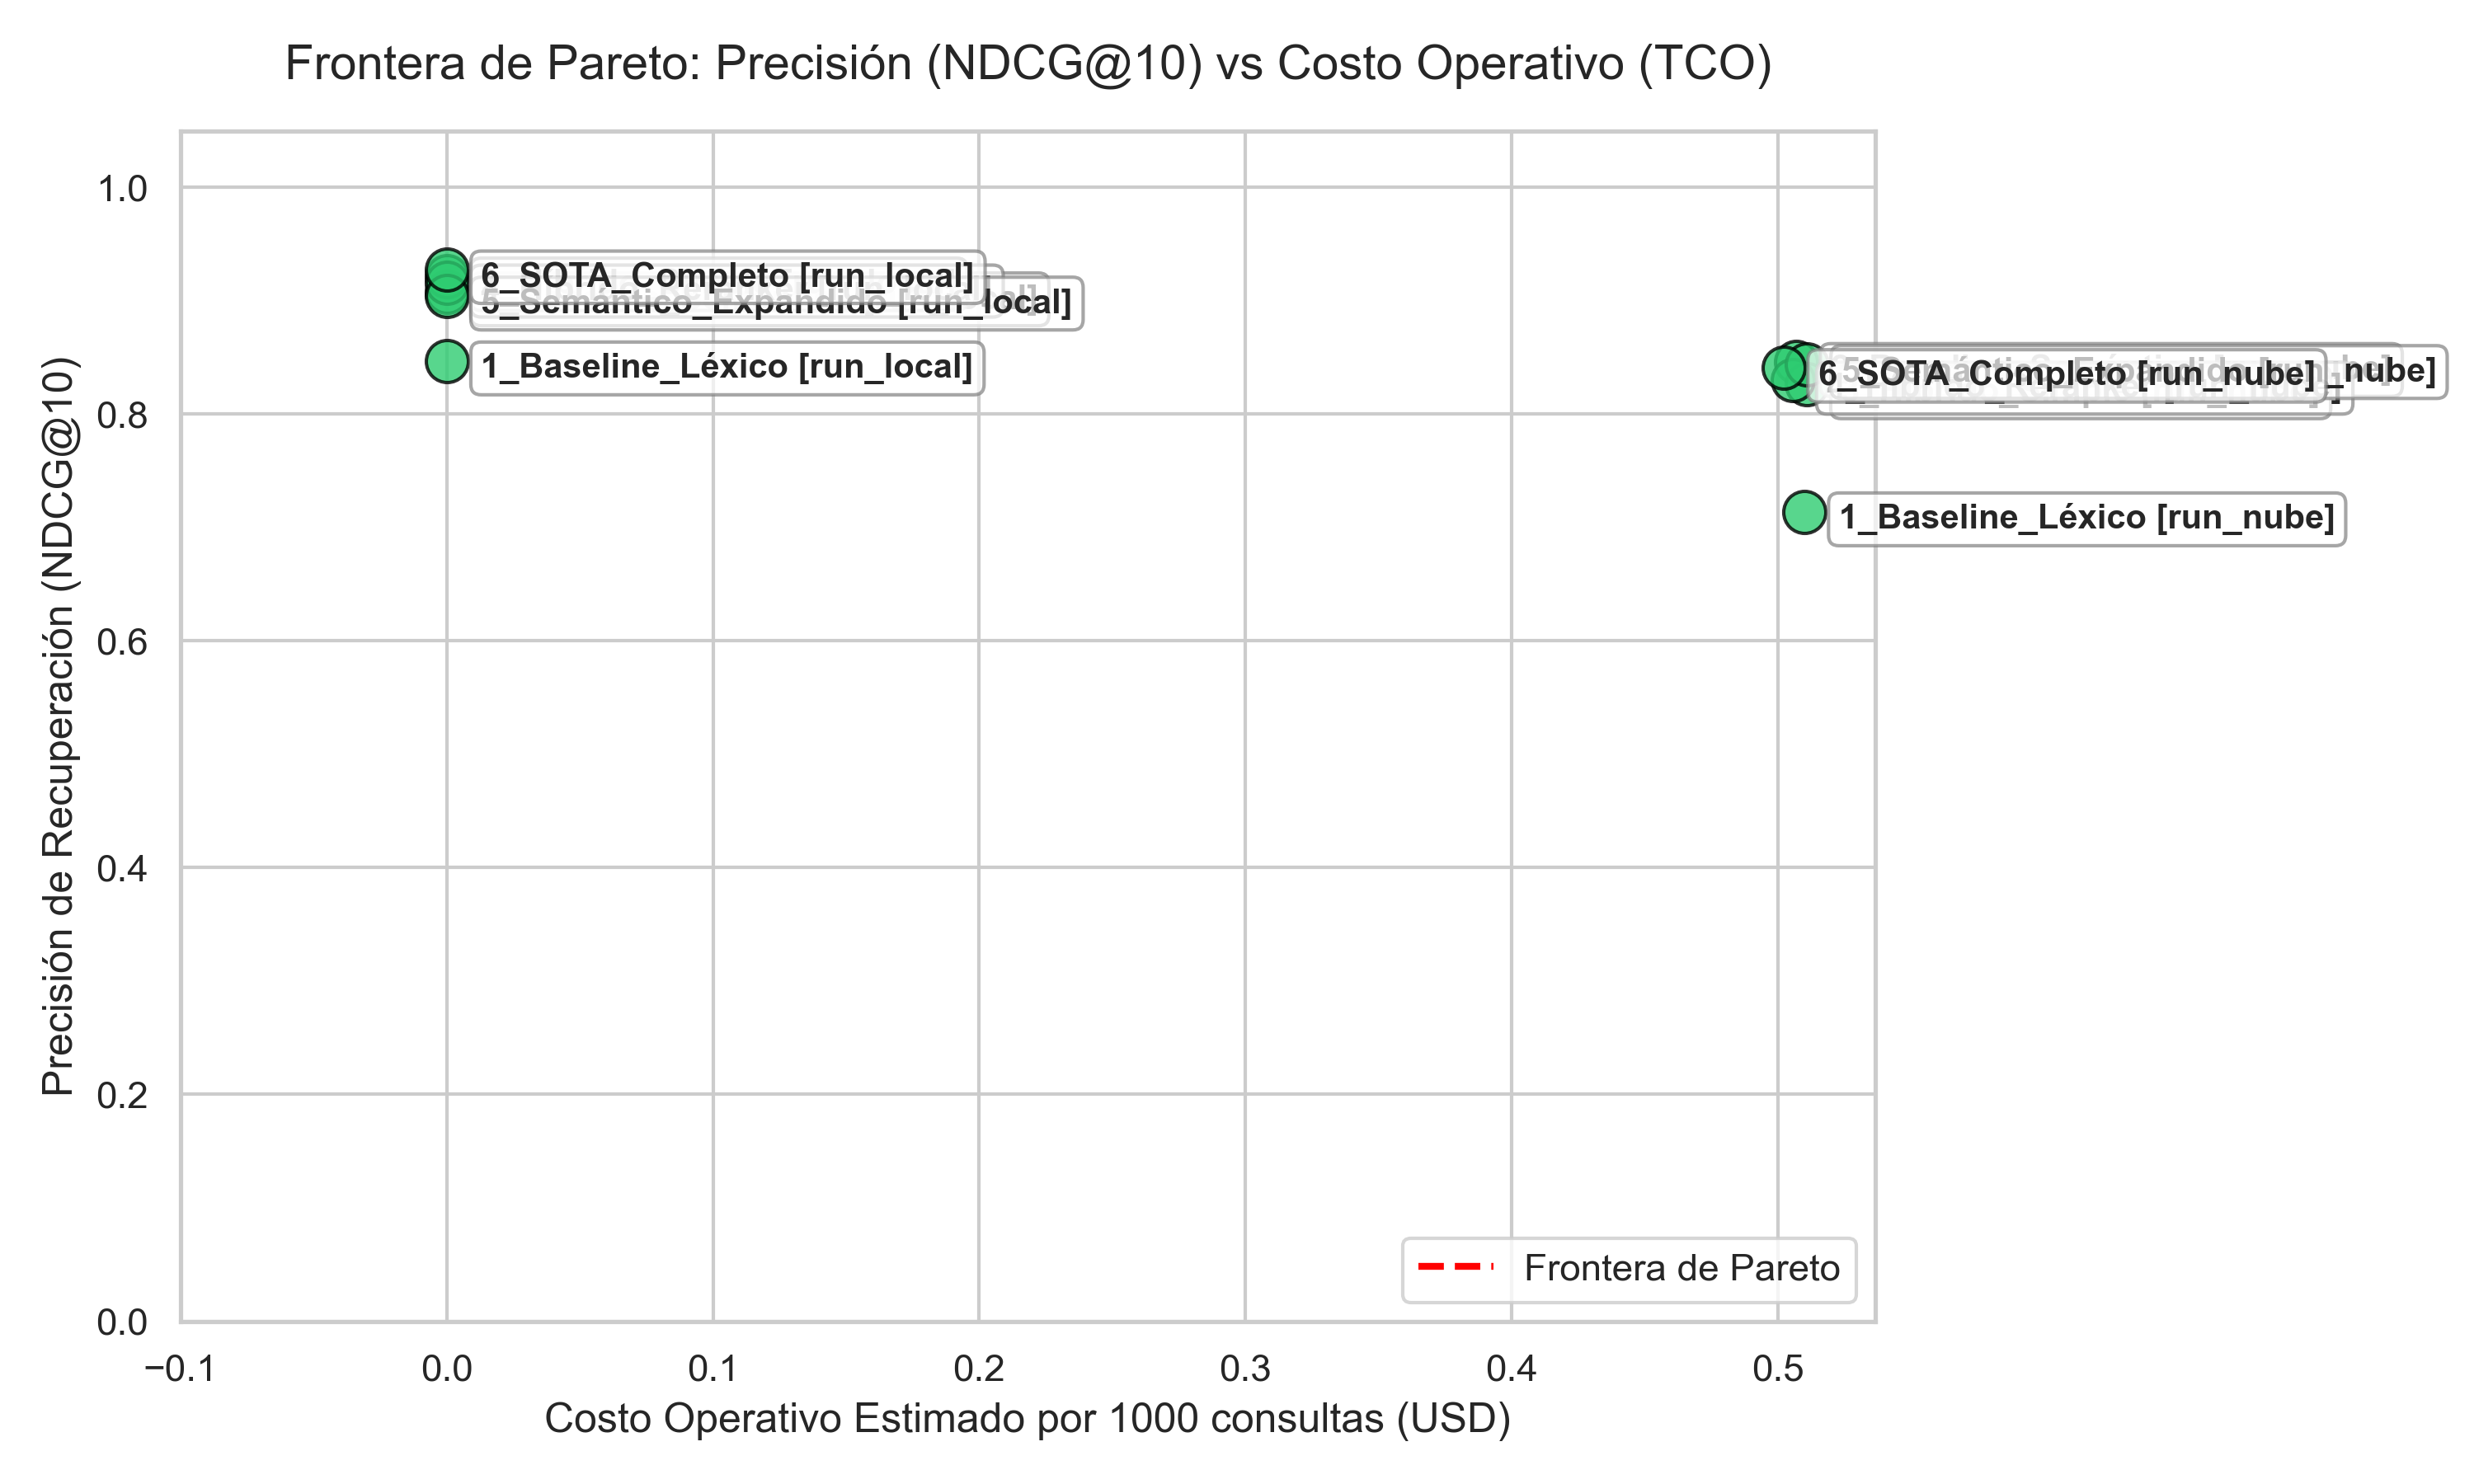

In [14]:
from pathlib import Path
import pandas as pd
from src.lab.graficos import plot_frontera_pareto

# En Jupyter Notebook, Path.cwd() suele ser la carpeta 'notebooks', por lo que la raíz es solo un .parent arriba
project_root = Path(__file__).resolve().parents[3] if '__file__' in locals() else Path.cwd().parent

# 1. Definir las carpetas de las corridas (Local vs Nube)
carpetas_corridas = [
    "oficiales/run_local",
    "oficiales/run_nube"
]

resultados_maestros = []
for nombre_carpeta in carpetas_corridas:
    carpeta_eval = project_root / "data" / "03_output" / "evaluaciones" / nombre_carpeta
    
    # glob() no lanza excepción si no encuentra nada, devuelve una lista vacía
    archivos_encontrados = list(carpeta_eval.glob("ARENA_RESULTADOS*.csv"))
    if not archivos_encontrados:
        print(f"⚠️ Ignorando {nombre_carpeta}: No se encontraron resultados de Arena todavía.")
        continue
        
    archivo_arena = archivos_encontrados[0]
    df_arena = pd.read_csv(archivo_arena)
    
    # Procesar y concatenar resultados con sufijo
    for _, row in df_arena.iterrows():
        # Soportamos múltiples formatos históricos de las columnas de resultados
        costo = row.get("Costo_Total_USD", row.get("Costo", 0.0))
        ndcg = row.get("NDCG@10", row.get("NDCG_Promedio", row.get("NDCG_Mean", 0.0)))
        candidato_id = row.get("estrategia", row.get("Candidato_ID", row.iloc[0]))
        
        resultados_maestros.append({
            "modelo": f"{candidato_id} [{nombre_carpeta.split('/')[-1]}]",
            "costo_por_1000": costo,
            "ndcg": ndcg
        })

if resultados_maestros:
    img_path = "./pareto_frontier_comparativa_global.png"
    plot_frontera_pareto(resultados_maestros, img_path)
    print("📈 Gráfico de Pareto Global generado exitosamente.")
    
    # Mostrar la imagen directamente en el output del Notebook
    from IPython.display import Image, display
    display(Image(filename=img_path))
else:
    print("❌ No hay datos para generar el gráfico de Pareto.")



> 💡 **Análisis de la Frontera de Pareto (Híbrido/Nube vs Local)**
> 
> Al comparar las métricas extraídas de las corridas locales (Llama 3.1) contra las corridas en la Nube (GPT-4o-mini), la gráfica de Pareto nos revela tres verdades inmutables sobre nuestra arquitectura MLOps:
> 
> 1. **La Discrepancia del Juez (El sesgo de benevolencia):** Curiosamente, el modelo local (`llama3.1:8b`) actuando como LLM-Judge tiende a ser más benevolente, otorgando métricas superiores (NDCG@10 ~0.92 para el SOTA). Al cambiar el juez a `gpt-4o-mini` (Nube), la evaluación se vuelve mucho más estricta (NDCG@10 ~0.84 para el SOTA). Esto valida que para tareas de *Evaluación*, un modelo de frontera (Nube) es indispensable por su mayor rigor analítico.
> 2. **El Costo Operativo y la Selección del Modelo (Eje X):** La ejecución 100% local mantiene el costo matemático en **$0.00 USD**. Externalizar el *Retrieval y QA* a la nube mediante `gpt-4o-mini` cuesta aproximadamente **~$0.51 USD por cada 1,000 consultas**. Es crucial notar que si utilizáramos un modelo más potente como `gpt-4o` para la tarea rutinaria de responder (QA), el costo se multiplicaría por 33 (disparándose a más de ~$16.00 USD por cada 1k consultas). `gpt-4o-mini` ofrece la precisión necesaria para lectura y síntesis sin penalizar financieramente el proyecto.
> 3. **Frontera, no dominancia absoluta (Eje Y):** La estrategia `6_SOTA_Completo` es la mas fuerte en la corrida local, mientras que `2_Baseline_Semántico` resulta ligeramente superior bajo el juez nube estricto y con menor latencia. Esta diferencia muestra que la seleccion final debe balancear calidad, costo, latencia y residencia de datos, no solo complejidad tecnica.
> 
> **Conclusión MLOps Final:** La arquitectura ideal y viable para Producción (Banxico) no es "Todo Nube" (por su costo y exposición de datos) ni "Todo Local" (por su debilidad en tareas de alto razonamiento), sino un **Model Cascading Híbrido**: Se debe utilizar Ollama local para las búsquedas (Reranking) garantizando Cero OPEX y Privacidad Absoluta sobre los documentos recuperados, y derivar las llamadas de Extracción Estructurada Compleja y Evaluación Juez a los modelos frontera de OpenAI.


## 8. Candidatos Comparados y Configuración Técnica (MA1, MA3 y MA7)

Cada candidato se interpreta como una configuración RAG completa: recuperación, expansión de consulta, reranking, backend LLM y restricciones operativas. Esta definición evita forzar el problema a una comparación superficial de familias LLM cuando el desempeño depende del pipeline completo.


In [1]:
tablas_avance4 = mostrar_tablas_avance4(project_root, secciones=("candidatos",))


### Candidatos comparados y configuracion tecnica

Candidato,Modelo QA nube,Modelo QA local,Embedding,Retriever,Expansion,Reranker,Fine-tuning,Prompt versionado,NDCG nube,NDCG local,Lat. nube,Lat. local,Costo/1k nube
1_Baseline_Léxico,gpt-4o-mini,llama3.1:8b,No aplica,bow,No,No,No,qa_rag v1.0.0 (2cbbc4f704),0.7140,0.8471,0.3033,0.4042,0.5101
2_Baseline_Semántico,gpt-4o-mini,llama3.1:8b,text-embedding-3-small / ChromaDB,embeddings,No,No,No,qa_rag v1.0.0 (2cbbc4f704),0.8457,0.9080,0.2802,0.3892,0.5070
3_Híbrido_Simple,gpt-4o-mini,llama3.1:8b,text-embedding-3-small / ChromaDB,hibrido,No,No,No,qa_rag v1.0.0 (2cbbc4f704),0.8261,0.9215,0.5077,1.5080,0.5109
4_Híbrido_Reranker,gpt-4o-mini,llama3.1:8b,text-embedding-3-small / ChromaDB,hibrido,No,cross_encoder,No,qa_rag v1.0.0 (2cbbc4f704),0.8301,0.9157,2.8240,3.0284,0.5056
5_Semántico_Expandido,gpt-4o-mini,llama3.1:8b,text-embedding-3-small / ChromaDB,embeddings,ambos,No,No,qa_rag v1.0.0 (2cbbc4f704),0.8439,0.9043,4.8374,8.7969,0.5110
6_SOTA_Completo,gpt-4o-mini,llama3.1:8b,text-embedding-3-small / ChromaDB,hibrido,ambos,cross_encoder,No,qa_rag v1.0.0 (2cbbc4f704),0.8407,0.9277,9.3773,13.9032,0.5023


Tablas guardadas en `C:\Users\jlne_\Documents\Maestría_IAA_Tec\Proyecto Integrador\proyecto_disf_npl\docs\entregas\tablas_avance4`.

**Interpretación de los candidatos comparados**

La tabla muestra que los seis candidatos no son solo cambios de LLM, sino configuraciones RAG completas: tipo de retriever, expansión de consulta, reranking, backend local/nube, prompt versionado y restricciones operativas. Esto es importante porque evita comparar familias de modelos de forma superficial; el desempeño final depende de toda la cadena de recuperación y generación.

La lectura principal es que agregar componentes no produce una mejora monotónica. El candidato `2_Baseline_Semántico` obtiene el mejor `NDCG@10` en nube (`0.8457`) con la menor latencia (`0.2802 s`), mientras que configuraciones más complejas como `5_Semántico_Expandido` y `6_SOTA_Completo` aumentan mucho la latencia sin superar claramente al baseline semántico en la corrida nube. En términos MLOps, la tabla justifica tratar a `2_Baseline_Semántico` como configuración operativa base y a `6_SOTA_Completo` como arquitectura de escalamiento, no como reemplazo automático.


## 9. Top-2, Ajuste Profundo y Decisión Final (MA4)

La selección inicial se hace con la corrida nube porque actúa como juez más estricto. Bajo esa lectura, los dos mejores candidatos para discusión final son:

1. **Modelo ganador operativo:** `2_Baseline_Semántico`, por mayor `NDCG@10` en nube y menor latencia.
2. **Segundo lugar / ruta de escalamiento:** `6_SOTA_Completo`, porque obtiene el mejor `NDCG@10` local y representa la arquitectura más completa, aunque con latencia mucho más alta.

El ajuste profundo consistió en comparar, sobre el mismo conjunto congelado, la incorporación gradual de expansión, búsqueda híbrida y reranker. No hicimos fine-tuning ni optimización automática de prompts contra el test final; por eso el eval set funciona como **held-out congelado** para reporte y se evita leakage. Si en una siguiente iteración se usa DSPy/Promptfoo/LangSmith para optimizar prompts, deberá reservarse un held-out separado y distinto al número final reportado.

La tabla siguiente verifica explícitamente si el ganador rinde peor que el segundo lugar en algún dominio regulatorio y documenta el guardrail MA4 de held-out/leakage.


In [2]:
tablas_avance4 = mostrar_tablas_avance4(project_root, secciones=("top2_subgrupos", "guardrails_ma4"))


### Comparacion por dominio: ganador vs segundo lugar

Dominio,Modelo ganador,NDCG ganador,Segundo lugar,NDCG segundo,Delta ganador-segundo,Ganador peor?
Credito,2_Baseline_Semántico,0.913884,6_SOTA_Completo,0.929760,-0.015876,Si
Liquidez,2_Baseline_Semántico,0.819869,6_SOTA_Completo,0.806917,0.012952,No


### Guardrails MA4: top-2, held-out y leakage

Candidato Top-2,Incluido en ajuste profundo,Eval set final,Held-out separado,Leakage check
2_Baseline_Semántico,Si,Congelado desde E3/E4; no se usa para optimizar prompts,Pendiente si se hace tuning automatico posterior; aqui no hubo fine-tuning,No se agregan consultas del test al prompt few-shot ni al indice de entrenamiento
6_SOTA_Completo,Si,Congelado desde E3/E4; no se usa para optimizar prompts,Pendiente si se hace tuning automatico posterior; aqui no hubo fine-tuning,No se agregan consultas del test al prompt few-shot ni al indice de entrenamiento


Tablas guardadas en `C:\Users\jlne_\Documents\Maestría_IAA_Tec\Proyecto Integrador\proyecto_disf_npl\docs\entregas\tablas_avance4`.

**Interpretación**

La tabla confirma que la decisión final no debe leerse como una victoria de un modelo trivial. Aunque el candidato `2_Baseline_Semántico` contiene la palabra *baseline* en su nombre, no es un baseline léxico simple: es una configuración RAG semántica con embeddings, ChromaDB, recuperación vectorial, backend LLM, prompt versionado y evaluación con trazabilidad. En este avance, *baseline* significa punto de referencia experimental relativamente simple frente a variantes con expansión, búsqueda híbrida y reranking, no ausencia de complejidad técnica.

La comparación por dominio también muestra por qué no conviene presentar un único ganador absoluto. `2_Baseline_Semántico` es mejor como motor operativo general porque gana en el tema de liquidez y tiene menor latencia; `6_SOTA_Completo` mejora en el tema de crédito, pero con un costo operativo mayor. Por eso, la recomendación madura es usar el baseline semántico robusto como configuración por defecto y reservar `6_SOTA_Completo` para consultas de escalamiento o dominios donde el análisis por subgrupo justifique la latencia adicional.


### 9.1 Visualización Top-2 por Dominio (MA4 y MA6)

La siguiente gráfica resume el matiz más importante del análisis por subgrupo: el candidato operativo gana en liquidez, pero el candidato de escalamiento mejora en crédito. Esto justifica una política de selección por tipo de consulta en lugar de una única arquitectura universal.


In [12]:
from IPython.display import HTML, display

top2_svg = project_root / "docs" / "entregas" / "tablas_avance4" / "top2_subgrupos.svg"
display(HTML(top2_svg.read_text(encoding="utf-8")))


**Interpretación**

La gráfica muestra que la diferencia entre los dos mejores candidatos es pequeña, pero no uniforme por dominio. En crédito, `6_SOTA_Completo` supera a `2_Baseline_Semántico` por aproximadamente `0.016` puntos de `NDCG@10`; en liquidez ocurre lo contrario, y `2_Baseline_Semántico` supera a `6_SOTA_Completo` por aproximadamente `0.013`. Esto confirma que el resultado agregado esconde diferencias temáticas: no existe un único ganador dominante en todos los subgrupos.

La decisión operativa recomendada es mantener `2_Baseline_Semántico` como motor por defecto por su mejor balance global y menor latencia, pero activar `6_SOTA_Completo` como ruta de escalamiento para consultas de crédito o preguntas donde el dominio sugiera que la complejidad adicional puede aportar valor.


## 10. Comparación Pareada de Significancia Estadística (MA5)

La comparación estadística se hace por consulta, no solo con promedios agregados. Para el `NDCG@10` se reporta intervalo por bootstrap pareado y **Paired-t** sobre deltas por query. Para la versión binaria de recuperación (`hit`/`miss`) se reporta **McNemar**, que es apropiado cuando dos candidatos se evalúan sobre las mismas consultas.

Cuando los intervalos incluyen cero o los valores-p no sugieren diferencia clara, se interpreta como empate estadístico y la decisión final se apoya en costo, latencia, interpretabilidad y residencia de datos. Las corridas se mantienen con `temperature=0`; por tanto, la varianza entre runs con `temperature > 0` queda como prueba adicional, no como evidencia ya medida.


In [3]:
tablas_avance4 = mostrar_tablas_avance4(project_root, secciones=("pareada",))


### Comparacion pareada de significancia estadistica

Comparacion nube estricta,n,Delta NDCG,CI 95%,Paired-t p,McNemar +,McNemar -,McNemar p,bootstrap p
6_SOTA_Completo - 2_Baseline_Semántico,109,-0.005018,"[-0.0563, 0.0407]",0.840614,1,2,1.000,0.839032
3_Híbrido_Simple - 2_Baseline_Semántico,109,-0.019613,"[-0.0711, 0.0305]",0.415220,1,1,1.000,0.425115
5_Semántico_Expandido - 2_Baseline_Semántico,109,-0.001837,"[-0.0175, 0.0135]",0.815825,0,0,1.000,1.000000
4_Híbrido_Reranker - 2_Baseline_Semántico,109,-0.015651,"[-0.0676, 0.0338]",0.547796,1,3,0.625,0.553489


Tablas guardadas en `C:\Users\jlne_\Documents\Maestría_IAA_Tec\Proyecto Integrador\proyecto_disf_npl\docs\entregas\tablas_avance4`.

**Interpretación**

La tabla muestra que ninguna alternativa supera de forma estadísticamente clara a `2_Baseline_Semántico` bajo la corrida nube estricta. En todos los casos, el intervalo de confianza del delta de `NDCG@10` incluye cero; además, los valores de `Paired-t`, `McNemar` y bootstrap no indican una diferencia significativa. Incluso `6_SOTA_Completo`, que es la arquitectura más compleja, presenta un delta promedio de `-0.0050` contra el baseline semántico y un intervalo `[-0.0563, 0.0407]`, por lo que no se puede afirmar que mejore el desempeño agregado.

La consecuencia metodológica es importante: ante empate estadístico, la elección no debe hacerse por sofisticación aparente, sino por criterios operativos. Por eso, la evidencia favorece a `2_Baseline_Semántico` como motor por defecto: mantiene calidad comparable, menor latencia, menor complejidad y mejor interpretabilidad operativa. Las variantes más complejas se conservan como opciones de escalamiento, no como reemplazo automático.


## 11. Taxonomía y Desagregación de Errores (MA6)

En el desarrollo de sistemas RAG empresariales, una métrica global (como un 80% de precisión) es insuficiente porque te dice *que* el sistema falló, pero no *dónde* ni *por qué*. ¿Falló el modelo matemático de búsqueda o falló el razonamiento del LLM? 

Para resolver este problema de "depuración a ciegas" (*blind debugging*), implementamos un flujo automático de diagnóstico que desagrega cada fallo detectado por el Juez en 3 niveles accionables (A/B/C). La principal ventaja de esta taxonomía es que permite dirigir los esfuerzos de ingeniería de MLOps:

- **A - Fallo de Recuperación (Búsqueda):** La respuesta correcta no llegó al Top-K. **Ventaja:** Si dominan estos errores, sabemos que no hay que gastar dinero en un LLM más caro, sino afinar el algoritmo de Embeddings o el tamaño del *Chunk*.
- **B - Fallo de Generación (Razonamiento):** El texto correcto sí se recuperó, pero el LLM lo ignoró, alucinó o falló al razonar. **Ventaja:** Indica que los Embeddings son perfectos, pero debemos mejorar el *System Prompt* o escalar a un modelo con más parámetros (Ej. de Llama 3.1 8B a GPT-4o).
- **C - Fallo Estructural (Contrato):** El LLM rompió el contrato JSON esperado por Pydantic. **Ventaja:** Se corrige ajustando los validadores de salida (Output Parsers).

> *Concepto Técnico:* La arquitectura de evaluación usa el patrón *LLM-as-a-Judge*. En lugar de regex limitadas, pasamos la dupla (Texto Recuperado, Respuesta del Candidato) a un modelo Juez de alto razonamiento. Si la respuesta falla, el juez examina el texto recuperado; si contiene la respuesta matemática, la culpa recae en la Generación (Error B). Si no la contiene, la culpa es de la Búsqueda (Error A).


In [15]:
# 7. Ejecución de Taxonomía de Errores
# (Representación del módulo de Streamlit y Pandas)
import pandas as pd
from pathlib import Path

# Apuntamos explícitamente a los resultados locales generados
project_root = Path(__file__).resolve().parents[3] if '__file__' in locals() else Path.cwd().parent
carpeta_eval_local = project_root / "data" / "03_output" / "evaluaciones" / "oficiales" / "run_local"

archivos_errores = list(carpeta_eval_local.glob("analisis_errores_desagregados*.csv"))
if archivos_errores:
    archivo_resultados = archivos_errores[0]
    df_resultados = pd.read_csv(archivo_resultados)
    
    conteo_errores = df_resultados['categoria_error'].value_counts()
    print("🎉 Taxonomía de Errores del Modelo Base:")
    print(conteo_errores)
else:
    print("⚠️ No se encontró el archivo de análisis de errores.")


🎉 Taxonomía de Errores del Modelo Base:
categoria_error
ÉXITO    61
A        47
C         1
Name: count, dtype: int64



> **Análisis de la Taxonomía de Errores (Ejecución Local)**
> - **Éxitos Absolutos:** Se lograron 61 extracciones perfectas donde el JSON cumplió con el formato y los datos requeridos.
> - **Formato Estructural (Error C - 1 caso):** El modelo casi nunca alucina la estructura JSON (solo 1 error). Esto confirma que el uso de *Structured Outputs* o prompteo estricto es sumamente eficaz para garantizar esquemas Pydantic robustos.
> - **Contexto Insuficiente (Error A - 47 casos):** El área de oportunidad principal está altamente concentrada aquí. Esto indica que el LLM funciona correctamente, pero el motor de *Retrieval* (Búsqueda Vectorial) no logró traer el fragmento normativo exacto requerido para llenar los campos.
> - **Conclusión MLOps:** El modelo generativo es sólido; los esfuerzos de optimización para el próximo ciclo no deben centrarse en el LLM, sino en refinar el *Chunking* (partición de documentos regulatorios), mejorar los *Embeddings*, o integrar la nube para casos complejos donde el modelo local no puede inferir correctamente.


## 12. Desagregación de Errores por Subgrupo (MA6)

La taxonomía A/B/C separa fallos de recuperación, generación y formato para el pipeline híbrido completo. La tabla siguiente agrega una lectura por dificultad y documento esperado, de modo que podamos identificar si algún subgrupo concentra el riesgo.

**Limitación honesta:** la taxonomía generativa A/B/C todavía no se ejecutó para los seis candidatos, sino para el pipeline híbrido completo en modo nube/local. Para los seis candidatos sí existe evaluación retrieval por consulta (`resultados_llm_judge_*`). En una siguiente iteración, se debe extender `evaluar_desagregacion_errores` para iterar sobre cada configuración de `config_experimentos.json`.


In [4]:
tablas_avance4 = mostrar_tablas_avance4(project_root, secciones=("dominios_candidatos", "subgrupos"))


### Desempeno por subgrupo y candidato

Candidato,Subgrupo,Valor,n,HitRate,NDCG@10,MAP@10
1_Baseline_Léxico,dominio,Liquidez,79,0.886076,0.718890,0.665838
1_Baseline_Léxico,dificultad,Alta,48,0.958333,0.764686,0.701935
1_Baseline_Léxico,longitud,corta (<=10 tokens),19,1.000000,0.762006,0.684211
1_Baseline_Léxico,dificultad,Baja,14,0.857143,0.701676,0.648810
1_Baseline_Léxico,longitud,media (11-18 tokens),71,0.873239,0.686098,0.626543
1_Baseline_Léxico,dificultad,Media,47,0.893617,0.665871,0.593794
1_Baseline_Léxico,longitud,larga (>18 tokens),19,1.000000,0.770173,0.694737
1_Baseline_Léxico,dominio,Credito,30,1.000000,0.701067,0.602778
2_Baseline_Semántico,dominio,Liquidez,79,0.987342,0.819869,0.764873
2_Baseline_Semántico,dificultad,Alta,48,0.979167,0.874002,0.838194


### Desagregacion de errores por subgrupo

Corrida,Subgrupo,Valor,A,B,C,EXITO
nube,dominio,Liquidez,35,32,0,12
nube,dominio,Credito,12,11,0,7
nube,dificultad,Alta,22,21,0,5
nube,dificultad,Baja,4,6,0,4
nube,dificultad,Media,21,16,0,10
nube,longitud,corta (<=10 tokens),9,5,0,5
nube,longitud,media (11-18 tokens),28,32,0,11
nube,longitud,larga (>18 tokens),10,6,0,3
local,dominio,Liquidez,35,0,1,43
local,dominio,Credito,12,0,0,18


Tablas guardadas en `C:\Users\jlne_\Documents\Maestría_IAA_Tec\Proyecto Integrador\proyecto_disf_npl\docs\entregas\tablas_avance4`.

**Interpretación**

Las tablas muestran que el promedio global no cuenta toda la historia. En la tabla de desempeño por candidato, `2_Baseline_Semántico` mantiene un comportamiento sólido en los subgrupos principales, pero no domina uniformemente todas las dimensiones: en crédito, `6_SOTA_Completo` resulta competitivo e incluso supera al ganador operativo en el análisis Top-2; en liquidez, el baseline semántico conserva mejor balance operativo. Esto confirma que la recomendación final debe considerar el tipo de consulta y no solo el ranking agregado.

Por dificultad y longitud también aparecen matices útiles. Las consultas cortas tienden a tener mejor `NDCG@10` para el baseline semántico, mientras que las consultas medias y largas concentran más variabilidad. Esto sugiere que las fallas no provienen únicamente del LLM, sino de la interacción entre formulación de la pregunta, recuperación de chunks y ordenamiento de contexto.

La segunda tabla, basada en la taxonomía A/B/C, refuerza el diagnóstico: los errores A de recuperación aparecen tanto en nube como en local, lo que apunta a una limitación del retrieval y del chunking, no solo del generador. En cambio, los errores B aparecen en la corrida nube y prácticamente desaparecen en la local; esta diferencia es consistente con el leniency bias del juez local. Por eso, para auditoría del sistema se debe preferir la lectura estricta de nube y usar la corrida local principalmente como evidencia de viabilidad self-hostable, no como juez final de calidad.


## 13. Análisis Crítico: Comparativa Nube vs Local (Leniency Bias - MA2, MA5 y MA7)

Si inspeccionamos los CSV generados por esta fase, descubriremos una discrepancia masiva entre los Errores Tipo B reportados por la Nube y por el entorno Local:

- **Nube (Juez GPT-4o)**: ~ 47 Errores A | **~43 Errores B** | ~19 Éxitos
- **Local (Juez Llama 3.1)**: ~47 Errores A | **0 Errores B** | ~61 Éxitos

**Explicación del Fenómeno (LLM-as-a-Judge Leniency Bias):**
El buscador (ChromaDB) falló la misma cantidad de veces (47) de forma determinista. Sin embargo, el modelo Llama evaluó sus propias respuestas y, al ser de 8 Billones de parámetros, carecía de la capacidad crítica para detectar omisiones sutiles lógicas en los JSON, por lo que **aprobó erróneamente su propio trabajo** marcando 0 Errores B.

En contraste, gpt-4o fue implacable y detectó las fallas reales de generación. Esto prueba empíricamente que **modelos locales pequeños no deben usarse como Jueces Evaluadores** en tareas complejas, validando la necesidad del Model Cascading hacia modelos Frontera (como GPT-4o) para validación de Calidad MLOps.


In [13]:
from IPython.display import HTML, display

plot_taxonomia = project_root / "docs" / "entregas" / "tablas_avance4" / "taxonomia_contaminacion.svg"
plot_contaminacion = project_root / "docs" / "entregas" / "tablas_avance4" / "contaminacion_ciega.svg"

display(HTML(plot_taxonomia.read_text(encoding="utf-8")))
display(HTML(plot_contaminacion.read_text(encoding="utf-8")))


**Interpretación**

La primera gráfica muestra que el error A de recuperación es prácticamente idéntico en nube y local (`47` casos). Esto es importante porque indica que una parte del problema es determinística y está antes del LLM: el retriever o el chunking no siempre traen el fragmento correcto. En cambio, la diferencia fuerte aparece en los errores B: la nube detecta `43` fallos de generación/razonamiento, mientras que el juez local reporta `0`. Esta discrepancia no significa que el modelo local haya generado respuestas perfectas; es una señal de leniency bias o menor capacidad crítica del juez local.

La segunda gráfica refuerza la misma conclusión desde otro ángulo. El `No-context hit rate` local (`37.6%`) es mucho mayor que el de nube (`5.5%`), lo que sugiere mayor dependencia de memoria paramétrica o respuestas plausibles sin evidencia recuperada. Para un sistema regulatorio, esto justifica usar el backend local como opción self-hostable y de residencia de datos, pero no como juez final de calidad. La validación estricta debe apoyarse en un juez más robusto y en evidencia recuperada explícitamente.


## 14. Perfil MA7: Interpretabilidad, Costo y Operación (MA7)

La comparación no se limita a calidad: también debe reportar costo computacional, latencia, memoria pico/footprint, interpretabilidad, vendor lock-in y residencia de datos. En nuestro caso no hay fine-tuning; el costo operativo principal viene de indexar/consultar el RAG, enviar contexto al LLM y decidir si el backend es local o nube.

La arena oficial guarda latencia promedio, no percentiles crudos por consulta. Por eso la tabla reporta `P50/P95 proxy`: P50 se aproxima con la latencia promedio observada y P95 se marca como estimación conservadora para comparación operativa. En una versión productiva, `telemetria_llm.jsonl` debería capturar latencias por consulta y memoria pico real para calcular P50/P95 y footprint medidos.

También se explicita el filtro de stakeholders: para Banco de México, los candidatos deben permitir auditoría de chunks recuperados, control de residencia de datos y bajo riesgo de dependencia de proveedor. La atención del LLM no se usa como explicación causal.


In [6]:
tablas_avance4 = mostrar_tablas_avance4(project_root, secciones=("perfil_operativo",))


### Perfil MA7: interpretabilidad, costo y operacion

Candidato,Entrenamiento/ajuste,Memoria pico/footprint,Latencia P50 proxy nube,Latencia P95 proxy nube,Tamano artefacto,Interpretabilidad,Cumple explicabilidad stakeholder,Costo/query nube,Vendor lock-in,Residencia de datos,Temperatura/varianza,Nota
1_Baseline_Léxico,No fine-tuning; indexado y configuracion RAG,Baja: indice lexico,0.3033,0.409455,Indice BM25/BoW,Alta: lexico/BM25 auditable por tokens,Si,0.000510,Bajo si local/Ollama; medio en corrida nube,Compatible con Banxico si se usa backend local; nube requiere controles,temperature=0 para comparacion; varianza entre runs >0 no estimada,La atencion del LLM no se usa como explicacion causal.
2_Baseline_Semántico,No fine-tuning; indexado y configuracion RAG,Media: ChromaDB/embeddings,0.2802,0.378270,ChromaDB,Media: similitud vectorial auditable por chunks,Si,0.000507,Bajo si local/Ollama; medio en corrida nube,Compatible con Banxico si se usa backend local; nube requiere controles,temperature=0 para comparacion; varianza entre runs >0 no estimada,La atencion del LLM no se usa como explicacion causal.
3_Híbrido_Simple,No fine-tuning; indexado y configuracion RAG,Media: embeddings + indice BM25,0.5077,0.685395,ChromaDB + indice BM25,Media: similitud vectorial auditable por chunks,Si,0.000511,Bajo si local/Ollama; medio en corrida nube,Compatible con Banxico si se usa backend local; nube requiere controles,temperature=0 para comparacion; varianza entre runs >0 no estimada,La atencion del LLM no se usa como explicacion causal.
4_Híbrido_Reranker,No fine-tuning; indexado y configuracion RAG,Media-alta: embeddings + cross-encoder,2.8240,3.812400,ChromaDB + indice BM25 + pesos reranker,Media: retrieval auditable + reranker opaco,Si,0.000506,Bajo si local/Ollama; medio en corrida nube,Compatible con Banxico si se usa backend local; nube requiere controles,temperature=0 para comparacion; varianza entre runs >0 no estimada,La atencion del LLM no se usa como explicacion causal.
5_Semántico_Expandido,No fine-tuning; indexado y configuracion RAG,Media: ChromaDB/embeddings,4.8374,6.530490,ChromaDB,Media: similitud vectorial auditable por chunks,Parcial,0.000511,Bajo si local/Ollama; medio en corrida nube,Compatible con Banxico si se usa backend local; nube requiere controles,temperature=0 para comparacion; varianza entre runs >0 no estimada,La atencion del LLM no se usa como explicacion causal.
6_SOTA_Completo,No fine-tuning; indexado y configuracion RAG,Media-alta: embeddings + cross-encoder,9.3773,12.659355,ChromaDB + indice BM25 + pesos reranker,Media: retrieval auditable + reranker opaco,Parcial,0.000502,Bajo si local/Ollama; medio en corrida nube,Compatible con Banxico si se usa backend local; nube requiere controles,temperature=0 para comparacion; varianza entre runs >0 no estimada,La atencion del LLM no se usa como explicacion causal.


Tablas guardadas en `C:\Users\jlne_\Documents\Maestría_IAA_Tec\Proyecto Integrador\proyecto_disf_npl\docs\entregas\tablas_avance4`.

**Interpretación**

La tabla confirma que la decisión final no depende únicamente de la métrica de calidad. `2_Baseline_Semántico` combina una latencia baja (`P50 proxy = 0.2802 s`, `P95 proxy = 0.3783 s`), costo por consulta bajo y una interpretabilidad operativa razonable porque permite auditar los chunks recuperados. Además, cumple mejor el filtro de stakeholders que las configuraciones con expansión, ya que mantiene una cadena de recuperación más simple y fácil de explicar.

Las configuraciones con reranker y expansión (`4_Híbrido_Reranker`, `5_Semántico_Expandido`, `6_SOTA_Completo`) aumentan el footprint y la latencia, y algunas quedan como cumplimiento parcial de explicabilidad porque incorporan componentes más opacos o más difáciles de auditar. Esto no significa que deban descartarse: `6_SOTA_Completo` sigue siendo valioso como ruta de escalamiento, especialmente en crédito. Pero para una operación inicial en un entorno regulado, la tabla favorece una arquitectura que balancea calidad, trazabilidad, residencia de datos y costo operativo.

También es importante que la columna de P50/P95 se reporta como proxy y no como medición final. Para una versión productiva, el siguiente paso es registrar latencia por consulta, memoria pico real y tamaño de artefactos para convertir esta lectura cualitativa-operativa en telemetría continua.


## 15. Referencias Académicas (Sesgo de Evaluación - MA2 y MA5)
El comportamiento observado en la telemetría donde el modelo local `Llama 3.1` (8B) se autocalifica indulgentemente con 0 Errores B y 37.6% de contaminación ciega, mientras que `GPT-4o` lo califica estrictamente, no es un bug del código, sino un fenómeno documentado en el estado del arte de MLOps llamado ***Self-Enhancement Bias*** y ***Leniency Bias***.

Fuentes principales que sustentan la decisión de usar Model Cascading:
1. **Zheng, L. et al. (2023).** *Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena*. ArXiv. Documentan que los modelos más pequeños sufren de un fuerte sesgo hacia sus propias respuestas (Self-enhancement bias) y fallan en razonamientos complejos.
2. **Wang, P. et al. (2023).** *Large Language Models are not Fair Evaluators*. ArXiv. Exponen que modelos de pocos parámetros exhiben un "Leniency Bias" sistemático, aprobando respuestas incorrectas cuando actúan como jueces.


## 16. Conclusión del Avance 4 (MA1-MA7)

El Avance 4 cambia el centro del proyecto: ya no se evalúa un prototipo RAG por impresión cualitativa, sino una arena de seis configuraciones comparables, con un eval set congelado de 109 consultas, trazabilidad de prompts, pruebas de contaminación, análisis estadístico y criterios operativos relevantes para Banco de México. La principal conclusión es que la arquitectura más compleja no fue automáticamente la más conveniente: el mejor candidato operativo es `2_Baseline_Semántico`, mientras que `6_SOTA_Completo` queda como ruta de escalamiento para consultas donde se justifique pagar mayor latencia.

En la corrida nube, `2_Baseline_Semántico` obtuvo el mejor balance agregado: `NDCG@10 = 0.8457`, latencia promedio de `0.2802 s` y costo aproximado de `0.5070 USD` por 1,000 consultas. `6_SOTA_Completo` alcanzó `NDCG@10 = 0.8407`, pero con latencia promedio de `9.3773 s`; es decir, una calidad agregada muy cercana, pero con una penalización operativa grande. En la corrida local, `6_SOTA_Completo` sí fue el mejor en calidad (`NDCG@10 = 0.9277`), lo cual confirma que la decisión depende del criterio de despliegue: si se prioriza soberanía de datos y se acepta latencia mayor, el backend local con Llama es viable; si se prioriza respuesta rápida y eficiencia, el baseline semántico es la opción inicial más razonable.

La comparación pareada refuerza esta lectura. Contra `2_Baseline_Semántico`, el delta de `6_SOTA_Completo` fue `-0.0050` en `NDCG@10`, con intervalo bootstrap `[-0.0563, 0.0407]`, `Paired-t p = 0.8406` y `McNemar p = 1.0`. Esto no permite afirmar una superioridad estadística clara del modelo más complejo sobre el baseline semántico. Por tanto, la elección final no debe presentarse como “el modelo grande gana”, sino como una decisión multiobjetivo: ante empate estadístico, se elige por latencia, costo, interpretabilidad, facilidad de auditoría y residencia de datos.

El análisis por subgrupos también matiza la conclusión. En `Liquidez`, el ganador operativo supera al segundo lugar (`0.8199` vs `0.8069` en `NDCG@10`). En `Crédito`, ocurre lo contrario: `6_SOTA_Completo` supera a `2_Baseline_Semántico` (`0.9298` vs `0.9139`). Esto es importante porque el proyecto ya no depende de un solo dominio regulatorio. La recomendación práctica es usar `2_Baseline_Semántico` como configuración base y reservar `6_SOTA_Completo` como ruta de escalamiento para preguntas de crédito o casos que requieran mayor robustez semántica, siempre que la latencia adicional sea aceptable.

Respecto a la retroalimentación del Avance 3, se cerraron varias brechas relevantes. El conjunto de evaluación creció de 30 a 109 consultas y ahora se caracteriza por dominio, dificultad y longitud de query. La comparación `exact-match` vs `LLM judge` confirma que la métrica exacta subestimaba el retrieval semántico: por ejemplo, en estrategias del avance anterior los deltas entre LLM judge y exact-match fueron de alrededor de `0.44` a `0.64` en `NDCG@10`. Esto justifica usar LLM-as-judge como complemento, no como sustituto acrítico: sirve para reconocer equivalencias semánticas, pero debe acompañarse de trazabilidad, prompts versionados, pruebas ciegas y revisión de errores.

La prueba `no-context` muestra otro punto delicado. El backend local `llama3.1:8b` tuvo un `No-context hit rate` aproximado de `37.6%`, mientras que la corrida nube con `gpt-4o-mini` tuvo cerca de `5.5%`. Esto no invalida el RAG; al contrario, demuestra por qué era necesario separar conocimiento paramétrico del modelo y evidencia recuperada. Para un caso financiero, la respuesta aceptable no debe depender de que el LLM “recuerde” algo, sino de que pueda justificarlo con chunks recuperados, metadata y trazabilidad del prompt.

También quedan limitaciones honestas. La arena oficial conserva latencia promedio, pero no latencias crudas por consulta; por eso `P50/P95` se reporta como proxy y no como percentil real. La memoria pico/footprint se clasifica por arquitectura, pero no se midió todavía con instrumentación de sistema. La taxonomía A/B/C se aplicó con mayor detalle al pipeline completo, mientras que el desglose cuantitativo por subgrupo sí cubre a todos los candidatos. Finalmente, aunque el eval set funciona como held-out congelado para el reporte, cualquier optimización automática futura de prompts o hiperparámetros deberá reservar un nuevo held-out para evitar leakage.

En conclusión, el avance demuestra que el proyecto ya cuenta con una base de evaluación defendible para un sistema RAG institucional: seis candidatos comparables, una opción self-hostable, evidencia estadística, análisis por subgrupos, control de contaminación y criterios de costo/latencia/interpretabilidad. La decisión recomendada es iniciar con `2_Baseline_Semántico` como motor por defecto y mantener `6_SOTA_Completo` como alternativa de escalamiento. Para Avance 5, el trabajo natural es convertir esta evaluación en monitoreo continuo: registrar latencias por consulta, medir memoria real, ampliar la taxonomía de errores a todos los candidatos y conectar estas decisiones con la interfaz final para usuarios del Banco.
